Dataset Loaded Successfully
   ID                             TITLE     GENRE  \
0   1      Oscar et la dame rose (2009)     drama   
1   2                      Cupid (1997)  thriller   
2   3  Young, Wild and Wonderful (1980)     adult   
3   4             The Secret Sin (1915)     drama   
4   5            The Unrecovered (2007)     drama   

                                         DESCRIPTION  
0  Listening in to a conversation between his doc...  
1  A brother and sister with a past incestuous re...  
2  As the bus empties the students for their fiel...  
3  To help their unemployed father make ends meet...  
4  The film's title refers not only to the un-rec...  

Dataset Shape: (54214, 4)

Missing Values:
ID             0
TITLE          0
GENRE          0
DESCRIPTION    0
dtype: int64

Genre Count:
GENRE
drama          13613
documentary    13096
comedy          7447
short           5073
horror          2204
thriller        1591
action          1315
western         1032
reality-tv

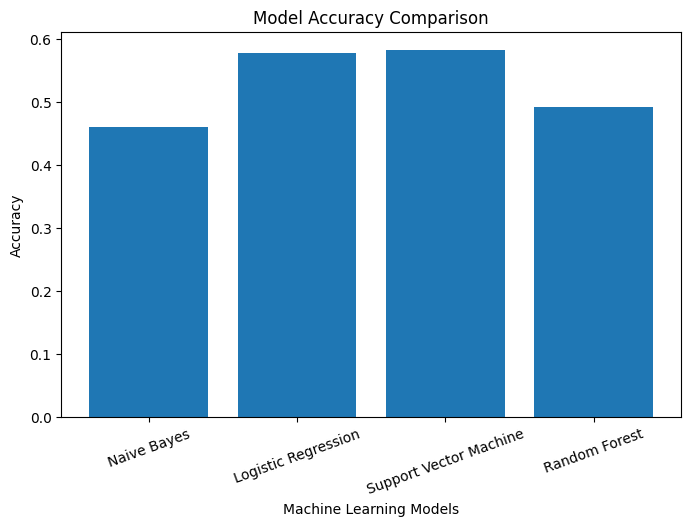

<Figure size 1200x1000 with 0 Axes>

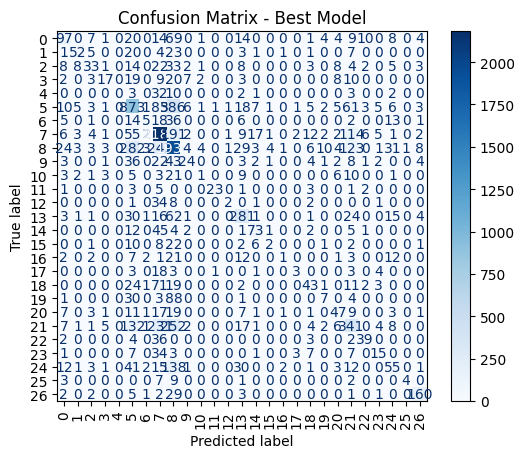


Prediction results saved as prediction_results.csv

Custom Movie Genre Predictions:

Movie Plot: A police officer fights dangerous criminals in a big city.
Predicted Genre: action

Movie Plot: A young couple falls in love but faces emotional family problems.
Predicted Genre: drama

Movie Plot: A group of friends enter a haunted house and experience terrifying events.
Predicted Genre: horror

Movie Plot: Aliens attack Earth and humans fight to save the planet.
Predicted Genre: sci-fi

Movie Plot: A poor man struggles to achieve success in life.
Predicted Genre: drama

Movie Plot: A detective investigates a mysterious murder case.
Predicted Genre: mystery

Enter a movie plot to predict genre: A group of friends enter a haunted house and experience terrifying events.
Predicted Genre: horror

Best model saved as movie_genre_model.pkl
TF-IDF vectorizer saved as tfidf_vectorizer.pkl

========== PROJECT SUMMARY ==========
Project Name: Movie Genre Classification
Dataset Used: train_data.txt


In [3]:

import pandas as pd
import numpy as np
import re
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

data = pd.read_csv(
    "train_data.txt",
    sep=" ::: ",
    engine="python",
    names=["ID", "TITLE", "GENRE", "DESCRIPTION"]
)

print("Dataset Loaded Successfully")
print(data.head())
print("\nDataset Shape:", data.shape)

print("\nMissing Values:")
print(data.isnull().sum())

print("\nGenre Count:")
print(data["GENRE"].value_counts())

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

data["CLEAN_DESCRIPTION"] = data["DESCRIPTION"].apply(clean_text)

print("\nCleaned Text Example:")
print(data[["DESCRIPTION", "CLEAN_DESCRIPTION"]].head())

X = data["CLEAN_DESCRIPTION"]
y = data["GENRE"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])


tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=70000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("\nTF-IDF Feature Shape:", X_train_tfidf.shape)


models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Support Vector Machine": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
predictions = {}

for name, model in models.items():
    print("\n================================")
    print("Model:", name)
    print("================================")

    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    predictions[name] = y_pred

    print("Accuracy:", acc)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

print("\nModel Accuracy Comparison:")
for model_name, acc in results.items():
    print(model_name, ":", acc)

best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
best_prediction = predictions[best_model_name]

print("\nBest Model:", best_model_name)
print("Best Accuracy:", results[best_model_name])


plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values())
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)
plt.show()

cm = confusion_matrix(y_test, best_prediction)

plt.figure(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(xticks_rotation="vertical", cmap="Blues")
plt.title("Confusion Matrix - Best Model")
plt.show()

prediction_df = pd.DataFrame({
    "Actual Genre": y_test.values,
    "Predicted Genre": best_prediction
})

prediction_df.to_csv("prediction_results.csv", index=False)

print("\nPrediction results saved as prediction_results.csv")

def predict_genre(movie_description):
    cleaned = clean_text(movie_description)
    vectorized = tfidf.transform([cleaned])
    prediction = best_model.predict(vectorized)
    return prediction[0]


sample_movies = [
    "A police officer fights dangerous criminals in a big city.",
    "A young couple falls in love but faces emotional family problems.",
    "A group of friends enter a haunted house and experience terrifying events.",
    "Aliens attack Earth and humans fight to save the planet.",
    "A poor man struggles to achieve success in life.",
    "A detective investigates a mysterious murder case."
]

print("\nCustom Movie Genre Predictions:")

for movie in sample_movies:
    print("\nMovie Plot:", movie)
    print("Predicted Genre:", predict_genre(movie))


user_movie = input("\nEnter a movie plot to predict genre: ")
print("Predicted Genre:", predict_genre(user_movie))


joblib.dump(best_model, "movie_genre_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("\nBest model saved as movie_genre_model.pkl")
print("TF-IDF vectorizer saved as tfidf_vectorizer.pkl")
print("\n========== PROJECT SUMMARY ==========")
print("Project Name: Movie Genre Classification")
print("Dataset Used: train_data.txt")
print("Technique Used: NLP + Machine Learning")
print("Vectorizer Used: TF-IDF")
print("Models Used:")
for model in models.keys():
    print("-", model)
print("Best Model:", best_model_name)
print("Best Accuracy:", results[best_model_name])
print("Files Generated:")
print("- prediction_results.csv")
print("- movie_genre_model.pkl")
print("- tfidf_vectorizer.pkl")
print("Task 1 Completed ")